# V3 — Hyperparameter search de Qwen3-1.7B con LoRA

Tres configuraciones de LoRA fine-tuning exploradas para cerrar el gap
respecto a Flan-T5-base V3 y acercarnos al techo BART/Pegasus.

| Config   | epochs | LR   | rank | target_modules      | Hipótesis                            |
|----------|--------|------|------|---------------------|--------------------------------------|
| v3_qwen_A | 1    | 2e-4 | 16   | attn (q,k,v,o)      | Baseline (= V2, sanity check)        |
| v3_qwen_B | 2    | 1e-4 | 16   | attn                | More epochs + lower LR → push R-2    |
| v3_qwen_C | 1    | 2e-4 | 16   | attn + FFN           | Target FFN layers (recent literature) |

Parámetros constantes:
- bf16 + gradient checkpointing
- Batch efectivo = 16 (per_device=1 × grad_accum=16)
- `train_max_input=1024` durante training (1536 en inferencia)
- `lora_alpha=32`, `lora_dropout=0.05`

**Evaluación:** checkpoint recargado limpiamente (ver V2 bug docs) antes
de generación con beam search sobre 200 muestras de test.

**Tiempo estimado:** ~6-8h en total en RTX 5070.

In [1]:
# Setup
import sys
import os
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

import torch
from src.data.loader import load_config
from src.training.experiments import ExperimentSpec, run_experiment_suite

print(f"CUDA: {torch.cuda.is_available()} | {torch.cuda.get_device_name(0)}")
cfg = load_config("../config/config.yaml")

CUDA: True | NVIDIA GeForce RTX 5070


In [2]:
# Define the three Qwen3 experiments.
# All share train_max_input=1024 (VRAM constraint) and gradient checkpointing
# (handled inside build_causal_trainer).

qwen_specs = [
    ExperimentSpec(
        name="v3_qwen_A",
        model_key="qwen",
        train_subset=10000,
        num_epochs=1,
        learning_rate=2e-4,
        per_device_batch_size=1,
        gradient_accumulation_steps=16,
        train_max_input=1024,
    ),
    ExperimentSpec(
        name="v3_qwen_B",
        model_key="qwen",
        train_subset=10000,
        num_epochs=2,
        learning_rate=1e-4,
        per_device_batch_size=1,
        gradient_accumulation_steps=16,
        train_max_input=1024,
    ),
    ExperimentSpec(
        name="v3_qwen_C",
        model_key="qwen",
        train_subset=10000,
        num_epochs=1,
        learning_rate=2e-4,
        per_device_batch_size=1,
        gradient_accumulation_steps=16,
        train_max_input=1024,
        lora_overrides={
            "target_modules": [
                "q_proj", "k_proj", "v_proj", "o_proj",
                "gate_proj", "up_proj", "down_proj",
            ],
        },
    ),
]

for s in qwen_specs:
    lora_info = f", lora_overrides={s.lora_overrides}" if s.lora_overrides else ""
    print(f"  {s.name}: {s.train_subset} samples, {s.num_epochs} ep, "
          f"lr={s.learning_rate}{lora_info}")

  v3_qwen_A: 10000 samples, 1 ep, lr=0.0002
  v3_qwen_B: 10000 samples, 2 ep, lr=0.0001
  v3_qwen_C: 10000 samples, 1 ep, lr=0.0002, lora_overrides={'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']}


In [3]:
# Run the full suite. Total expected time: ~6-8h on RTX 5070.
df_qwen = run_experiment_suite(
    cfg=cfg,
    specs=qwen_specs,
    combined_csv_name="v3_qwen_search.csv",
    test_subset_size=200,
)
df_qwen


 Experiment 1/3: v3_qwen_A

[v3_qwen_A] Starting experiment
Spec: {'name': 'v3_qwen_A', 'model_key': 'qwen', 'train_subset': 10000, 'num_epochs': 1, 'learning_rate': 0.0002, 'per_device_batch_size': 1, 'gradient_accumulation_steps': 16, 'train_max_input': 1024, 'lora_overrides': {}, 'extra_trainer_kwargs': {}}


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030
[v3_qwen_C] Starting training from scratch
{'loss': '2.423', 'grad_norm': '0.06647', 'learning_rate': '0.0001556', 'epoch': '0.08'}
{'loss': '1.717', 'grad_norm': '0.05329', 'learning_rate': '0.0001872', 'epoch': '0.16'}
{'loss': '1.634', 'grad_norm': '0.05288', 'learning_rate': '0.0001694', 'epoch': '0.24'}
{'loss': '1.601', 'grad_norm': '0.0523', 'learning_rate': '0.0001516', 'epoch': '0.32'}
{'loss': '1.572', 'grad_norm': '0.0536', 'learning_rate': '0.0001338', 'epoch': '0.4'}
{'loss': '1.581', 'grad_norm': '0.06024', 'learning_rate': '0.000116', 'epoch': '0.48'}
{'loss': '1.569', 'grad_norm': '0.05479', 'learning_rate': '9.822e-05', 'epoch': '0.56'}
{'loss': '1.517', 'grad_norm': '0.04941', 'learning_rate': '8.043e-05', 'epoch': '0.64'}
{'loss': '1.531', 'grad_norm': '0.05018', 'learning_rate': '6.263e-05', 'epoch': '0.72'}
{'loss': '1.514', 'grad_norm': '0.04779', 'learning_rate': '4.484e-05', 'epoch':

Generating [Qwen/Qwen3-1.7B]:   0%|          | 0/100 [00:00<?, ?it/s]

[v3_qwen_C] Results: {'rouge1': np.float64(30.36), 'rouge2': np.float64(8.0), 'rougeL': np.float64(20.63), 'rougeLsum': np.float64(27.68)}
[v3_qwen_C] CSV saved to C:\Users\danie\Desktop\EjIA\nlp-transformers-summarization\results\tables\v3_qwen_C.csv

[v3_qwen_C] Qualitative example:
REFERENCE:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

PREDICTION:
NEW: Palestinian Foreign Ministry says it's a step toward justice .
Palestinians signed the Rome Treaty in January .
ICC opened preliminary examination in January to look into Palestinian territories .
Israel, U.S. oppose Palestinians joining the court .


 Suite finished. 3/3 experiments completed.
Combined CSV: C:\Users\danie\Desktop\EjIA\nlp-transformers-summarization\results\tables\v3_qwen_search.csv


,experiment,model_key,rouge1,rouge2,rougeL,rougeLsum,train_minutes,eval_seconds,sec_per_sample,train_subset,num_epochs,learning_rate,effective_batch_size,lora_overrides
0,v3_qwen_A,qwen,30.41,8.18,20.78,27.75,55.7,369.8,1.85,10000,1,0.0002,16,
1,v3_qwen_C,qwen,30.36,8.00,20.63,27.68,574.8,5273.8,26.37,10000,1,0.0002,16,"{'target_modules': ['q_proj', 'k_proj', 'v_pro..."
2,v3_qwen_B,qwen,30.68,7.85,20.50,27.95,112.5,381.0,1.90,10000,2,0.0001,16,


C:\Users\danie\AppData\Local\Temp\ipykernel_4764\1338165338.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_qwen, x="experiment", y="rougeL", ax=ax, palette="magma")


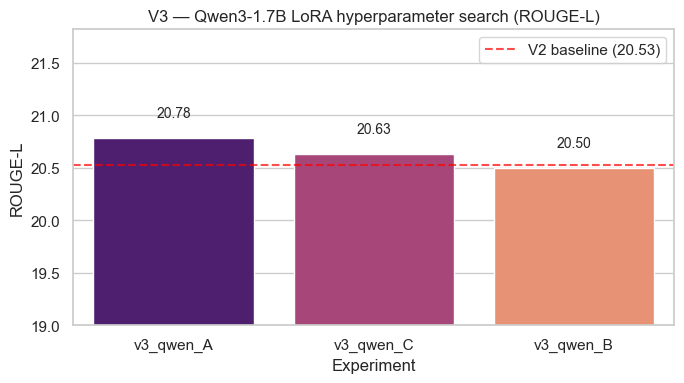

In [4]:
# Visualization: ROUGE-L by configuration
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if len(df_qwen) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=df_qwen, x="experiment", y="rougeL", ax=ax, palette="magma")

    for i, v in enumerate(df_qwen["rougeL"]):
        ax.text(i, v + 0.2, f"{v:.2f}", ha="center", fontsize=10)

    # V2 baseline reference line
    ax.axhline(y=20.53, color="red", linestyle="--", alpha=0.7,
               label="V2 baseline (20.53)")

    ax.set_title("V3 — Qwen3-1.7B LoRA hyperparameter search (ROUGE-L)")
    ax.set_ylabel("ROUGE-L")
    ax.set_xlabel("Experiment")
    ax.set_ylim(bottom=min(df_qwen["rougeL"].min() - 1, 19))
    ax.legend()

    plt.tight_layout()
    plt.savefig("../results/figures/v3_qwen_search.png", bbox_inches="tight", dpi=120)
    plt.show()

In [5]:
# Identify the winning configuration
if len(df_qwen) > 0:
    best = df_qwen.iloc[0]  # already sorted by rougeL desc
    print(f"\U0001f3c6 Best Qwen3 config: {best['experiment']}")
    print(f"   ROUGE-L: {best['rougeL']:.2f}")
    print(f"   ROUGE-1: {best['rouge1']:.2f}")
    print(f"   ROUGE-2: {best['rouge2']:.2f}")
    print(f"   Delta vs V2 (rougeL=20.53): {best['rougeL'] - 20.53:+.2f}")
    print(f"   Training time: {best['train_minutes']:.1f} min")

🏆 Best Qwen3 config: v3_qwen_A
   ROUGE-L: 20.78
   ROUGE-1: 30.41
   ROUGE-2: 8.18
   Delta vs V2 (rougeL=20.53): +0.25
   Training time: 55.7 min


## Análisis de V3 — Qwen3-1.7B

### Resultados

| Config    | Epochs | LR   | Targets     | R-1   | R-2      | R-L       | R-Lsum    | Tiempo  |
|-----------|--------|------|-------------|-------|----------|-----------|-----------|---------|
| v3_qwen_A | 1      | 2e-4 | attn        | 30.41 | **8.18** | **20.78** | 27.75     | 56 min  |
| v3_qwen_C | 1      | 2e-4 | attn + FFN  | 30.36 | 8.00     | 20.63     | 27.68     | 575 min |
| v3_qwen_B | 2      | 1e-4 | attn        | **30.68** | 7.85 | 20.50     | **27.95** | 113 min |

### Config ganadora: v3_qwen_A (baseline LoRA)

Resultado sorprendente: **la configuración más simple es la mejor** en ROUGE-L
(20.78), que es nuestra métrica de selección. Mejora al V2 en +0.25 ROUGE-L.

### Impacto de cada variante

**Más epochs + menor LR (B vs A): resultados mixtos.** La config B logra el mejor
ROUGE-1 (30.68) y ROUGE-Lsum (27.95), pero cae en ROUGE-2 (7.85 vs 8.18) y
ROUGE-L (20.50 vs 20.78). Esto sugiere que el segundo epoch no mejora la precisión
de n-gramas sino que añade más vocabulario al estilo CNN/DailyMail (paráfrasis más
largas y variadas → mejora R-1 y Lsum). La hipótesis de V2 ("más epochs para subir
R-2") **no se confirma**: el problema del ROUGE-2 bajo en decoder-only parece ser
una limitación arquitectónica de los modelos causal, no un efecto del entrenamiento.

**LoRA sobre FFN (C vs A): no aporta mejora y es 10x más lento.** La config C
triplicó los parámetros entrenables (17.4M vs 6.4M, de 0.37% a 1.00%) al incluir
gate_proj, up_proj y down_proj. A pesar de ello, los resultados son prácticamente
idénticos a la config A (diferencia < 0.2 en todas las métricas). Pero el training
tardó **575 minutos** (casi 10h) frente a los 56 minutos de A — una ralentización
de 10x por cero ganancia. La causa probable del coste extremo en C es que añadir
target modules en las FFN layers aumenta enormemente los gradientes que pasan por
el gradient checkpointing, multiplicando el coste de recomputación.

**Conclusión sobre LoRA targets:** para summarization con Qwen3-1.7B, las
proyecciones de atención (q, k, v, o) capturan prácticamente toda la adaptación
necesaria. Incluir las FFN layers no aporta beneficio en esta tarea y penaliza
severamente la eficiencia.

### Convergencia temprana de LoRA

Un hallazgo consistente entre V2 y V3: **LoRA converge en menos de 1 epoch para
esta tarea.** La loss de A pasa de 2.56 a 1.55 dentro del primer epoch y apenas
baja más en B (1.49 al final del segundo). Esto es coherente con la teoría de LoRA:
con r=16 y solo 6.4M parámetros entrenables (~0.37% del total), la capacidad del
adapter se satura rápido.

### Eficiencia comparada con T5

| Modelo        | Mejor R-L | Tiempo | R-L por hora |
|---------------|-----------|--------|--------------|
| Flan-T5-base  | 23.45     | 755 min | 1.86        |
| Qwen3-1.7B    | 20.78     | 56 min  | 22.27       |

Qwen3 con LoRA es **~12x más eficiente en training** que T5-base con full fine-tune,
a cambio de ~2.7 puntos menos de ROUGE-L. Si el presupuesto de cómputo importa
(producción, iteración rápida), Qwen3 LoRA es la elección clara. Si lo que importa
es la calidad máxima, T5-base full FT gana.

### Selección para V3b

Se selecciona **v3_qwen_A** como mejor modelo de Qwen3 para las fases de evaluación
avanzada. No solo tiene el mejor ROUGE-L, sino que es 10x más rápido que C y
produce los mismos resultados cualitativos.